In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import time

In [2]:
top_flatearth_comments = pd.read_csv("top_users_top_comments_flatearth.csv")
top_chemtrails_comments = pd.read_csv("top_users_top_comments_chemtrails.csv")
top_aliens_comments = pd.read_csv("top_users_top_comments_aliens.csv")
top_news_comments = pd.read_csv("top_users_top_comments_news.csv")

In [3]:
df_dict = {
    "flatearth": top_flatearth_comments,
    "chemtrails": top_chemtrails_comments,
    "aliens": top_aliens_comments,
    "news": top_news_comments,
}

In [15]:
from openai import OpenAI

client = OpenAI(api_key=api_key, base_url="https://services.clarin-pl.eu/api/v1/oapi")

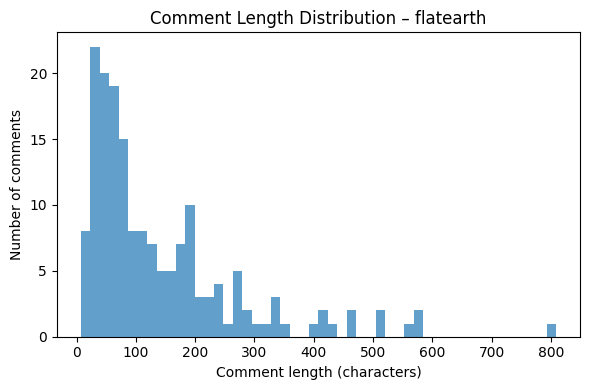

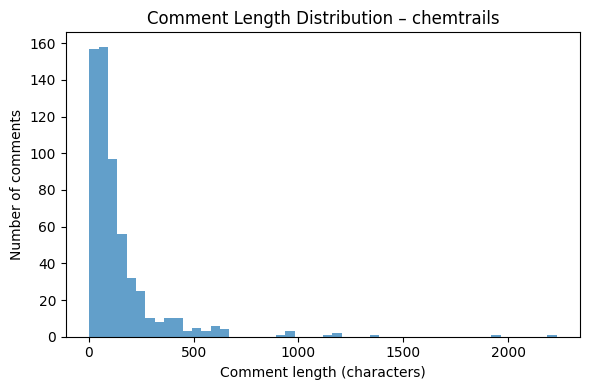

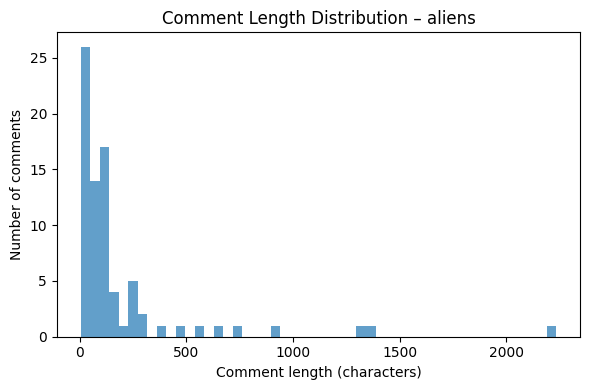

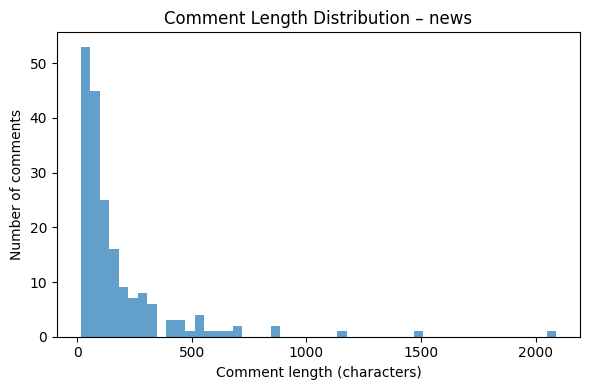

In [15]:
for name, df in df_dict.items():
    lengths = df["content"].astype(str).str.len()

    plt.figure(figsize=(6, 4))
    plt.hist(lengths, bins=50, alpha=0.7)
    plt.title(f"Comment Length Distribution – {name}")
    plt.xlabel("Comment length (characters)")
    plt.ylabel("Number of comments")
    plt.tight_layout()
    plt.show()

# LLM as a judge

In [9]:
def get_full_df_id_to_content(subreddit):
    full_df = pd.read_csv(f'{subreddit}.csv')
    return dict(zip(full_df["activity_id"], full_df["content"]))

In [55]:
def build_comment_prompt(comment, parent_content, categories, max_text_length = 1000):
    categories_desc = 'No categories defined yet' if not categories else ", ".join(categories)
    return f"""
    Categories: {categories_desc}
    
    Parent content: 
    {parent_content[:max_text_length]}

    Comment content:
    {comment['content'][:max_text_length]}
    """

from openai import OpenAI

client = OpenAI(api_key=api_key, base_url="https://services.clarin-pl.eu/api/v1/oapi")

def get_llm_response(prompt, model="llama3.3"):
    response = client.chat.completions.create(
        model=model,
        messages=[
            {
                "role": "system",
                "content": """Your task is to classify the INTENTION/STRATEGY of a Reddit comment author based on their response to a parent post/comment.
                Focus on the function the comment serves in the discussion ecosystem (e.g., escalating conflict, providing evidence, mocking, bridging gaps).

                Input:
                - Parent content: Context of the conversation.
                - Comment content: The text to classify.
                - Existing Categories: A list of standardized labels.

                Guidelines:
                1. *Create new categories if needed:* If none of the existing categories clearly match, you should create a new category.
                2. *Naming Convention:* If creating a new category, use UPPERCASE_SNAKE_CASE. Keep it abstract (e.g., AUTHORITY_APPEAL instead of QUOTING_NASA). Don't create various variants of the same strategy (e.g. single 'DEBUNKING' category rather than 'DEBUNKING_WITH IMPLIED_CORRUPTION' and 'DEBUNKING_WITH_ALTERNATIVE_EXPLANATION').
                3. *Context Matters:* Consider the relationship. Is the comment agreeing, debunking, expanding, or derailing?

                Output format:
                Return ONLY the category name. No explanations, no punctuation.
                """
            },
            {
                "role": "user",
                "content": prompt
            }
        ],
        temperature=0.2,
        timeout=30
    )
    return response.choices[0].message.content

In [56]:
import time
from tqdm import tqdm

def get_categories(subreddit, categories = None):
    comments_dataframe = df_dict[subreddit]
    print(f"Getting categories for {len(comments_dataframe)} comments")

    comments_categories = categories or set()
    index_to_category = {}
    full_df_id_to_content = get_full_df_id_to_content(subreddit)

    for index, row in tqdm(comments_dataframe.iterrows()):
        parent_content = full_df_id_to_content[row['parent_id']]
        prompt = build_comment_prompt(row, parent_content, comments_categories)
        
        while True:
            try:
                category = get_llm_response(prompt)
                time.sleep(0.2)
                break
            except:
                time.sleep(10)
        
        index_to_category[index] = category
        comments_categories.add(category)

    return index_to_category
    


In [59]:
flatearth_categories = get_categories('flatearth')
flatearth_categories

Getting categories for 170 comments


170it [01:53,  1.49it/s]


{0: 'DEBUNKING_WITH_EVIDENCE',
 1: 'DEBUNKING_WITH_EVIDENCE',
 2: 'DEBUNKING_WITH_EVIDENCE',
 3: 'DERAILING_WITH_INDIFFERENCE',
 4: 'SHOWING_APPRECIATION',
 5: 'DERAILING_WITH_INDIFFERENCE',
 6: 'DERAILING_WITH_INDIFFERENCE',
 7: 'DERAILING_WITH_INDIFFERENCE',
 8: 'DEBUNKING_WITH_EVIDENCE',
 9: 'DEBUNKING_WITH_EVIDENCE',
 10: 'DEBUNKING_WITH_EVIDENCE',
 11: 'DERAILING_WITH_INDIFFERENCE',
 12: 'DERAILING_WITH_INDIFFERENCE',
 13: 'DERAILING_WITH_INDIFFERENCE',
 14: 'DERAILING_WITH_INDIFFERENCE',
 15: 'DEBUNKING_WITH_EVIDENCE',
 16: 'DEBUNKING_WITH_EVIDENCE',
 17: 'DERAILING_WITH_INDIFFERENCE',
 18: 'DERAILING_WITH_INDIFFERENCE',
 19: 'DEBUNKING_WITH_EVIDENCE',
 20: 'DEBUNKING_WITH_EVIDENCE',
 21: 'DERAILING_WITH_INDIFFERENCE',
 22: 'DEBUNKING_WITH_EVIDENCE',
 23: 'DERAILING_WITH_INDIFFERENCE',
 24: 'DERAILING_WITH_INDIFFERENCE',
 25: 'SHOWING_APPRECIATION',
 26: 'DERAILING_WITH_INDIFFERENCE',
 27: 'AMPLIFYING_INDIGNATION',
 28: 'DERAILING_WITH_INDIFFERENCE',
 29: 'DERAILING_WITH_INDIFFER

In [61]:
df_dict['flatearth']["category"] = df_dict['flatearth'].index.map(flatearth_categories)
df_dict['flatearth'].head()

,activity_id,activity_type,timestamp,subreddit,author,parent_id,parent_type,content,permalink,score,...,num_replies,reply_delay_sec,median_reply_seconds,response_speed,replies_log,score_log,comment_ignition_score,sentiment,ignition_score_mean,category
0,t1_nox5pny,comment,2025-11-15 03:12:27+00:00,flatearth,Just_Ear_2953,t3_1oxggea,post,We HAVE repeatedly observed and measured the c...,https://www.reddit.com/r/flatearth/comments/1o...,104.493,...,4.0,1361.0,2984.0,0.005695,0.456402,1.000000,0.479625,-0.9042,0.479625,DEBUNKING_WITH_EVIDENCE
1,t1_nox4zax,comment,2025-11-15 03:07:31+00:00,flatearth,Polenicus,t3_1oxggea,post,"Ah yes, declaring Science has been scientifica...",https://www.reddit.com/r/flatearth/comments/1o...,36.000,...,0.0,1065.0,NaN,0.000000,0.000000,0.775101,0.193775,0.4019,0.193775,DEBUNKING_WITH_EVIDENCE
2,t1_noxb8j7,comment,2025-11-15 03:50:28+00:00,flatearth,Freaiser,t1_nox5pny,comment,They indeed found a drift....a 15 ° per hour d...,https://www.reddit.com/r/flatearth/comments/1o...,43.000,...,1.0,2281.0,391.0,0.043367,0.196562,0.812294,0.312196,0.0000,0.312196,DEBUNKING_WITH_EVIDENCE
3,t1_noxehpa,comment,2025-11-15 04:13:54+00:00,flatearth,Flatulatory,t1_nox5pny,comment,“Interesting…”,https://www.reddit.com/r/flatearth/comments/1o...,27.000,...,1.0,3687.0,1612.0,0.010539,0.196562,0.715273,0.279734,0.0000,0.279734,DERAILING_WITH_INDIFFERENCE
4,t1_noxc5u7,comment,2025-11-15 03:56:59+00:00,flatearth,MasterPat2015,t1_noxb8j7,comment,Thanks Bob.,https://www.reddit.com/r/flatearth/comments/1o...,25.000,...,1.0,391.0,29678.0,0.000573,0.196562,0.699366,0.273265,0.4404,0.273265,SHOWING_APPRECIATION


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

def show_categories_histogram(_df):
    sns.set(style="whitegrid")

    plt.figure(figsize=(8, 5))

    sns.countplot(
        data=_df,
        x="category",
        order=_df["category"].value_counts().index,
        palette="tab10"
    )

    plt.title("Number of comments per category")
    plt.xlabel("Category")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


C:\Users\marci\AppData\Local\Temp\ipykernel_10336\2108455297.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


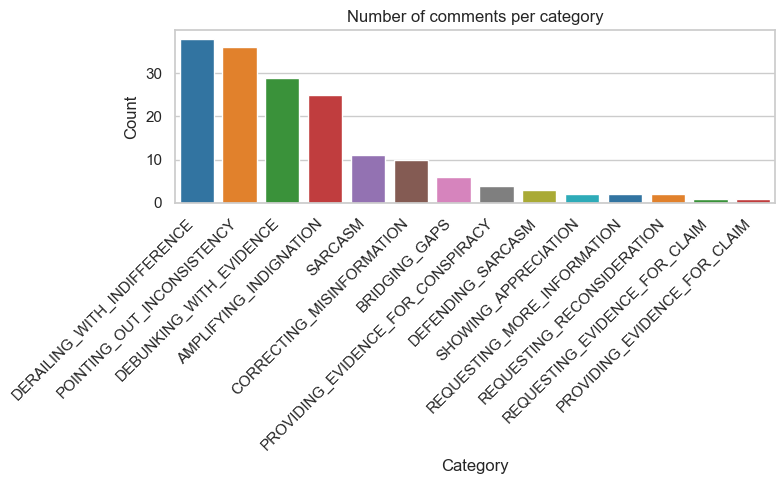

In [62]:
show_categories_histogram(df_dict['flatearth'])

In [70]:
categories = set(df_dict['flatearth']['category'].unique().tolist())
categories

{'AMPLIFYING_INDIGNATION',
 'BRIDGING_GAPS',
 'CORRECTING_MISINFORMATION',
 'DEBUNKING_WITH_EVIDENCE',
 'DEFENDING_SARCASM',
 'DERAILING_WITH_INDIFFERENCE',
 'POINTING_OUT_INCONSISTENCY',
 'PROVIDING_EVIDENCE_FOR_CLAIM',
 'PROVIDING_EVIDENCE_FOR_CONSPIRACY',
 'REQUESTING_EVIDENCE_FOR_CLAIM',
 'REQUESTING_MORE_INFORMATION',
 'REQUESTING_RECONSIDERATION',
 'SARCASM',
 'SHOWING_APPRECIATION'}

Getting categories for 78 comments


78it [00:53,  1.46it/s]
C:\Users\marci\AppData\Local\Temp\ipykernel_10336\2108455297.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


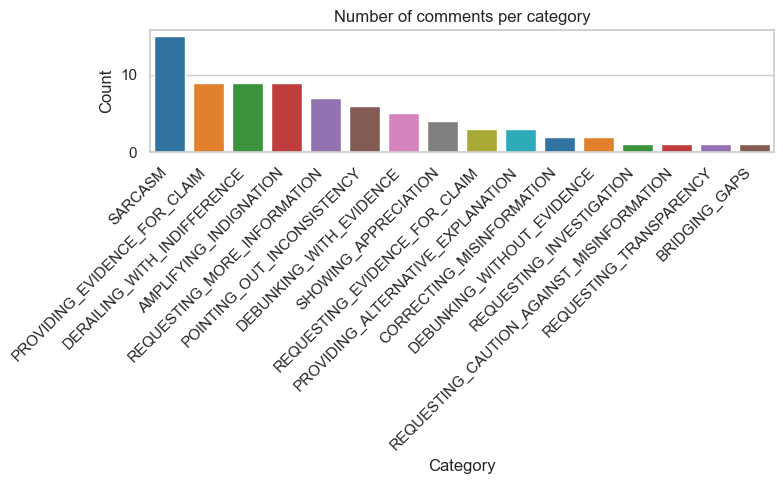

In [71]:
aliens_categories = get_categories('aliens', categories)
df_dict['aliens']["category"] = df_dict['aliens'].index.map(aliens_categories)
categories.update(set(aliens_categories.values()))
show_categories_histogram(df_dict['aliens'])

Getting categories for 594 comments


594it [06:57,  1.42it/s]
C:\Users\marci\AppData\Local\Temp\ipykernel_10336\2108455297.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


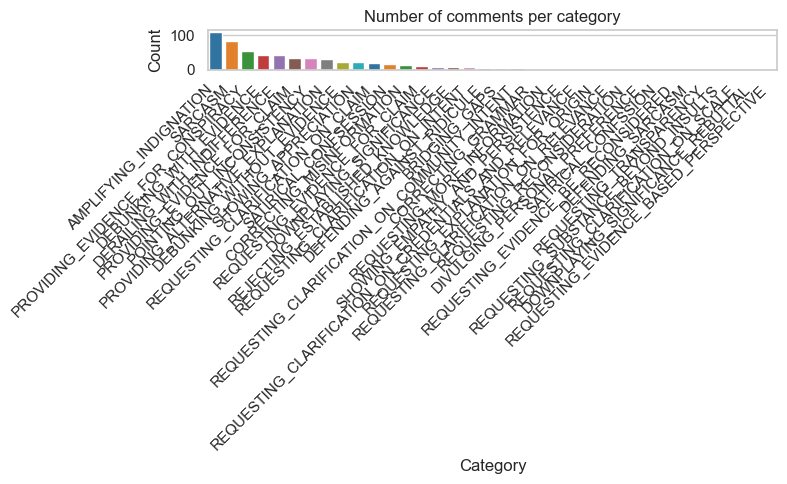

In [72]:
chemtrails_categories = get_categories('chemtrails', categories)
df_dict['chemtrails']["category"] = df_dict['chemtrails'].index.map(chemtrails_categories)
categories.update(set(chemtrails_categories.values()))
show_categories_histogram(df_dict['chemtrails'])

Getting categories for 190 comments


190it [02:15,  1.40it/s]
C:\Users\marci\AppData\Local\Temp\ipykernel_10336\2108455297.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


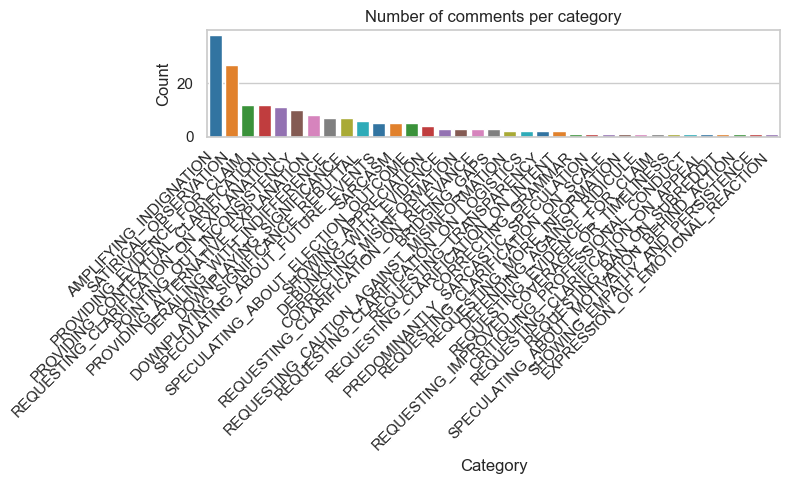

In [73]:
news_categories = get_categories('news', categories)
df_dict['news']["category"] = df_dict['news'].index.map(news_categories)
categories.update(set(news_categories.values()))
show_categories_histogram(df_dict['news'])

In [77]:
df_dict["flatearth"]["category"].value_counts().head(10)

category
DERAILING_WITH_INDIFFERENCE          38
POINTING_OUT_INCONSISTENCY           36
DEBUNKING_WITH_EVIDENCE              29
AMPLIFYING_INDIGNATION               25
SARCASM                              11
CORRECTING_MISINFORMATION            10
BRIDGING_GAPS                         6
PROVIDING_EVIDENCE_FOR_CONSPIRACY     4
DEFENDING_SARCASM                     3
SHOWING_APPRECIATION                  2
Name: count, dtype: int64

In [ ]:
top_flatearth_categories = flatearth_categories

In [80]:
categories

{'AMPLIFYING_INDIGNATION',
 'BRIDGING_GAPS',
 'CORRECTING_GRAMMAR',
 'CORRECTING_MISINFORMATION',
 'CRITIQUING_PROFESSIONAL_CONDUCT',
 'DEBUNKING_WITHOUT_EVIDENCE',
 'DEBUNKING_WITH_EVIDENCE',
 'DEFENDING_AGAINST_RIDICULE',
 'DEFENDING_SARCASM',
 'DERAILING_WITH_INDIFFERENCE',
 'DIVULGING_PERSONAL_PREFERENCE',
 'DOWNPLAYING_SIGNIFICANCE',
 'DOWNPLAYING_SIGNIFICANCE_REBUTTAL',
 'EXPRESSION_OF_EMOTIONAL_REACTION',
 'POINTING_OUT_INCONSISTENCY',
 'PREDOMINANTLY_SARCASTIC_SPECULATION',
 'PROVIDING_ALTERNATIVE_EXPLANATION',
 'PROVIDING_CONTEXTUAL_CLARIFICATION',
 'PROVIDING_EVIDENCE_FOR_CLAIM',
 'PROVIDING_EVIDENCE_FOR_CONSPIRACY',
 'REJECTING_ESTABLISHED_KNOWLEDGE',
 'REQUESTING_BAN_ON_SUBREDDIT',
 'REQUESTING_CAUTION_AGAINST_MISINFORMATION',
 'REQUESTING_CLARIFICATION_ON_APPEAL',
 'REQUESTING_CLARIFICATION_ON_CLAIM',
 'REQUESTING_CLARIFICATION_ON_COMMUNITY_INTENT',
 'REQUESTING_CLARIFICATION_ON_CREDENTIALS_AND_RELEVANCE',
 'REQUESTING_CLARIFICATION_ON_EXPLANATION',
 'REQUESTING_CLARIFICAT

In [90]:
response = client.chat.completions.create(
    model="llama3.3",
    messages=[
        {
            "role": "user",
            "content": f"""Below is a list of defined comment categories. You should narrow down the categories list to 10 general categories.
            Return a JSON list of ten final categories.
            Existing categories: {", ".join(categories)}
            """
        }
    ],
    temperature=0.2,
    timeout=30
)

In [ ]:
response_str = response.choices[0].message.content
response_str

'After analyzing the existing categories, I have narrowed them down to 10 general categories. Here is the JSON list of the final categories:\n\n```json\n[\n  "REQUESTING_CLARIFICATION",\n  "CORRECTING_MISINFORMATION",\n  "SHOWING_EMOTION_OR_EMPATHY",\n  "SPECULATING_OR_PREDICTING",\n  "REQUESTING_INFORMATION",\n  "PROVIDING_INFORMATION",\n  "CRITIQUING_OR_DEBUNKING",\n  "REQUESTING_ACTION",\n  "EXPRESSION_OF_OPINION",\n  "SATIRE_OR_SARCASM"\n]\n```\n\nThese categories cover the main themes and ideas present in the original list, including:\n\n* Requesting clarification or more information\n* Correcting misinformation or providing accurate information\n* Expressing emotions or empathy\n* Speculating or predicting future events\n* Requesting evidence or proof\n* Providing information or context\n* Critiquing or debunking ideas or actions\n* Requesting action or change\n* Expressing opinions or perspectives\n* Using satire or sarcasm to make a point.'

In [20]:
import json
response_json_dict = '[\n  "REQUESTING_CLARIFICATION",\n  "CORRECTING_MISINFORMATION",\n  "SHOWING_EMOTION_OR_EMPATHY",\n  "SPECULATING_OR_PREDICTING",\n  "REQUESTING_INFORMATION",\n  "PROVIDING_INFORMATION",\n  "CRITIQUING_OR_DEBUNKING",\n  "REQUESTING_ACTION",\n  "EXPRESSION_OF_OPINION",\n  "SATIRE_OR_SARCASM"\n]'
final_categories = json.loads(response_json_dict)
final_categories

['REQUESTING_CLARIFICATION',
 'CORRECTING_MISINFORMATION',
 'SHOWING_EMOTION_OR_EMPATHY',
 'SPECULATING_OR_PREDICTING',
 'REQUESTING_INFORMATION',
 'PROVIDING_INFORMATION',
 'CRITIQUING_OR_DEBUNKING',
 'REQUESTING_ACTION',
 'EXPRESSION_OF_OPINION',
 'SATIRE_OR_SARCASM']

In [30]:
def build_final_comment_prompt(comment, parent_content, max_text_length = 1000):
    return f"""
    Categories: {", ".join(final_categories)}
    
    Parent content: 
    {parent_content[:max_text_length]}

    Comment content:
    {comment['content'][:max_text_length]}
    """

def get_final_llm_response(prompt, model="llama3.3"):
    messages = [
        {
            "role": "system",
            "content": f"""Your task is to classify the INTENTION/STRATEGY of a Reddit comment author based on their response to a parent post/comment.
            Focus on the function the comment serves in the discussion ecosystem (e.g., escalating conflict, providing evidence, mocking, bridging gaps).

            Input:
            - Parent content: Context of the conversation.
            - Comment content: The text to classify.

            Guidelines:
            1. *Use only one of existing categories:* Select the best matching category from the defined list: {", ".join(final_categories)}.

            Output format:
            Return ONLY the category name. No explanations, no punctuation. You must choose one of the provided categories. 
            """
        },
        {
            "role": "user",
            "content": prompt
        }
    ]
    response = client.chat.completions.create(
        model=model,
        messages=messages,
        temperature=0.2,
        timeout=30
    )
    return response.choices[0].message.content

In [36]:
def get_final_categories(subreddit):
    final_categories_set = set(final_categories)
    comments_dataframe = df_dict[subreddit]
    print(f"Getting categories for {len(comments_dataframe)} comments")

    index_to_category = {}
    full_df_id_to_content = get_full_df_id_to_content(subreddit)

    for index, row in tqdm(comments_dataframe.iterrows()):
        parent_content = full_df_id_to_content[row['parent_id']]
        prompt = build_final_comment_prompt(row, parent_content)
        
        try:
            category = get_final_llm_response(prompt)
            if category not in final_categories_set:
                print(f'Invalid category: {category}')
                raise Exception('Invalid category')
        except:
            category = 'OTHER'
        
        time.sleep(0.2)
        index_to_category[index] = category

    return index_to_category
    


Getting categories for 170 comments


170it [01:55,  1.47it/s]
C:\Users\marci\AppData\Local\Temp\ipykernel_5680\2108455297.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


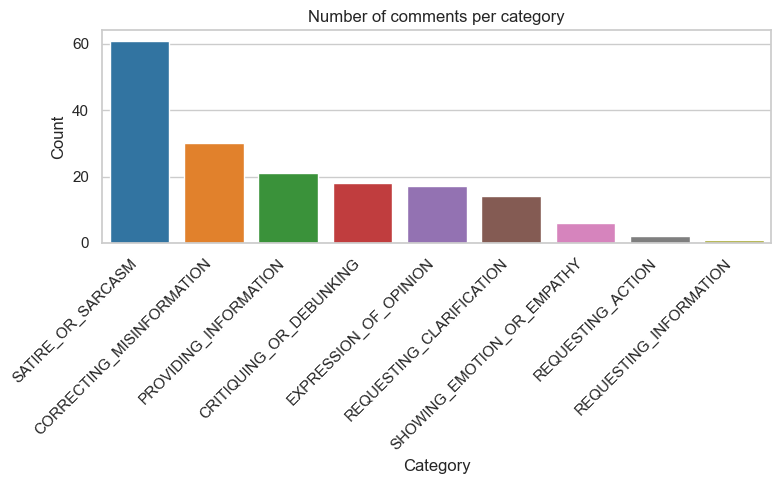

In [27]:
flatearth_categories = get_final_categories('flatearth')
df_dict['flatearth']["category"] = df_dict['flatearth'].index.map(flatearth_categories)
show_categories_histogram(df_dict['flatearth'])

Getting categories for 78 comments


78it [00:52,  1.49it/s]
C:\Users\marci\AppData\Local\Temp\ipykernel_5680\2108455297.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


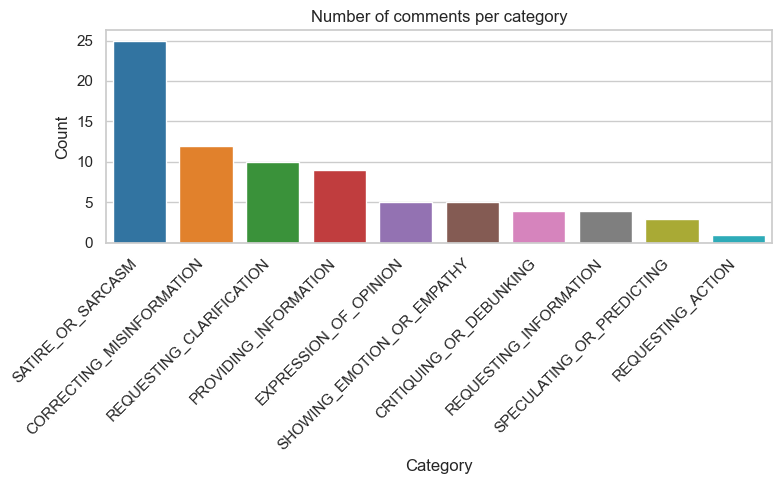

In [28]:
aliens_categories = get_final_categories('aliens')
df_dict['aliens']["category"] = df_dict['aliens'].index.map(aliens_categories)
show_categories_histogram(df_dict['aliens'])

Getting categories for 594 comments


297it [03:14,  1.50it/s]

Invalid category: DEFENDING_AGAINST_CRITICISM_is not in the list, the closest match is 
EXPRESSION_OF_OPINION


594it [06:33,  1.51it/s]
C:\Users\marci\AppData\Local\Temp\ipykernel_5680\2108455297.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


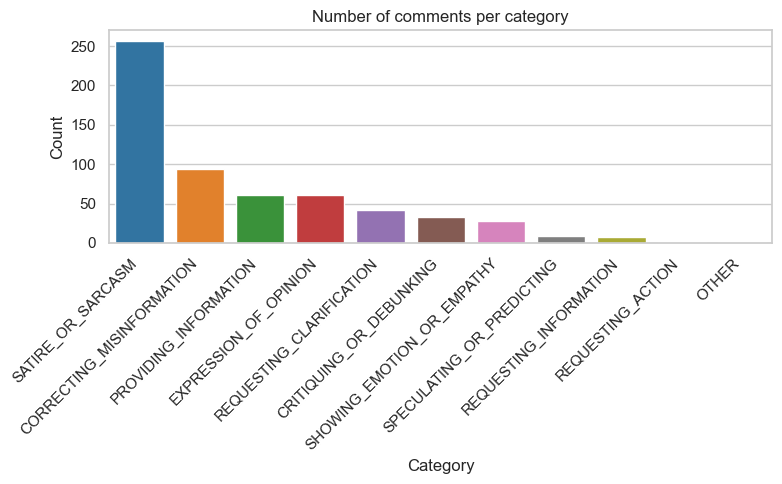

In [37]:
chemtrails_categories = get_final_categories('chemtrails')
df_dict['chemtrails']["category"] = df_dict['chemtrails'].index.map(chemtrails_categories)
show_categories_histogram(df_dict['chemtrails'])

Getting categories for 190 comments


190it [02:05,  1.51it/s]
C:\Users\marci\AppData\Local\Temp\ipykernel_5680\2108455297.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


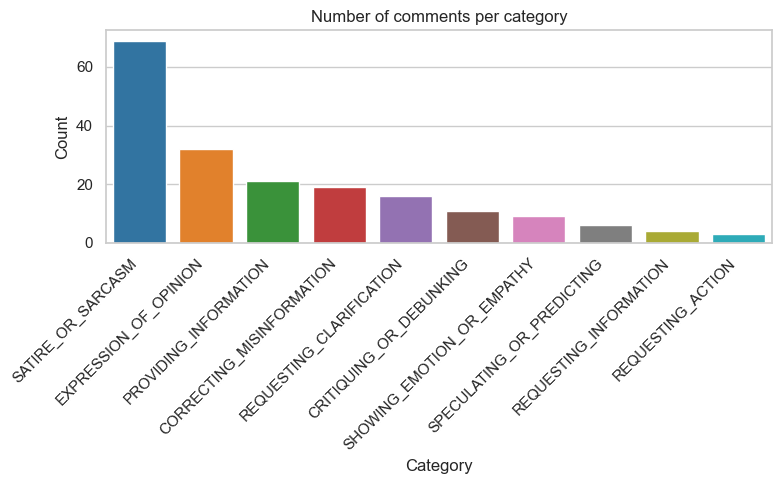

In [33]:
news_categories = get_final_categories('news')
df_dict['news']["category"] = df_dict['news'].index.map(news_categories)
show_categories_histogram(df_dict['news'])

In [39]:
for name, _df in df_dict.items():
    _df.to_csv(f'{name}_top_comments_with_categories.csv')

In [41]:
df_dict['news'][df_dict['news']['category'] == 'OTHER']

,activity_id,activity_type,timestamp,subreddit,author,parent_id,parent_type,content,permalink,score,...,num_replies,reply_delay_sec,median_reply_seconds,response_speed,replies_log,score_log,comment_ignition_score,sentiment,ignition_score_mean,category


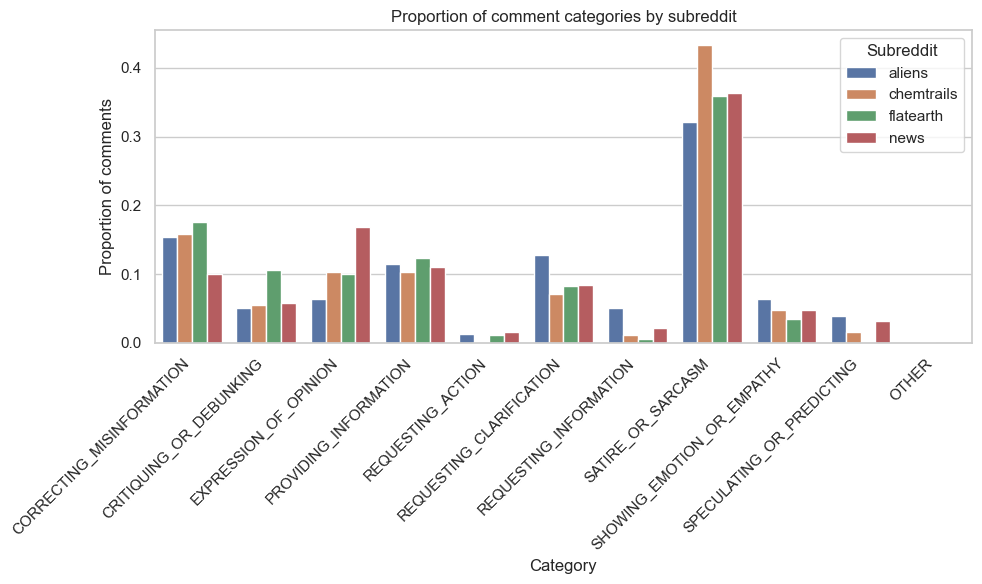

In [40]:
all_df = pd.concat(list(df_dict.values()), ignore_index=True)
category_props = (
    all_df
    .groupby(["subreddit", "category"])
    .size()
    .reset_index(name="count")
)

category_props["proportion"] = (
    category_props["count"]
    / category_props.groupby("subreddit")["count"].transform("sum")
)

sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_props,
    x="category",
    y="proportion",
    hue="subreddit"
)

plt.title("Proportion of comment categories by subreddit")
plt.xlabel("Category")
plt.ylabel("Proportion of comments")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Subreddit")
plt.tight_layout()
plt.show()

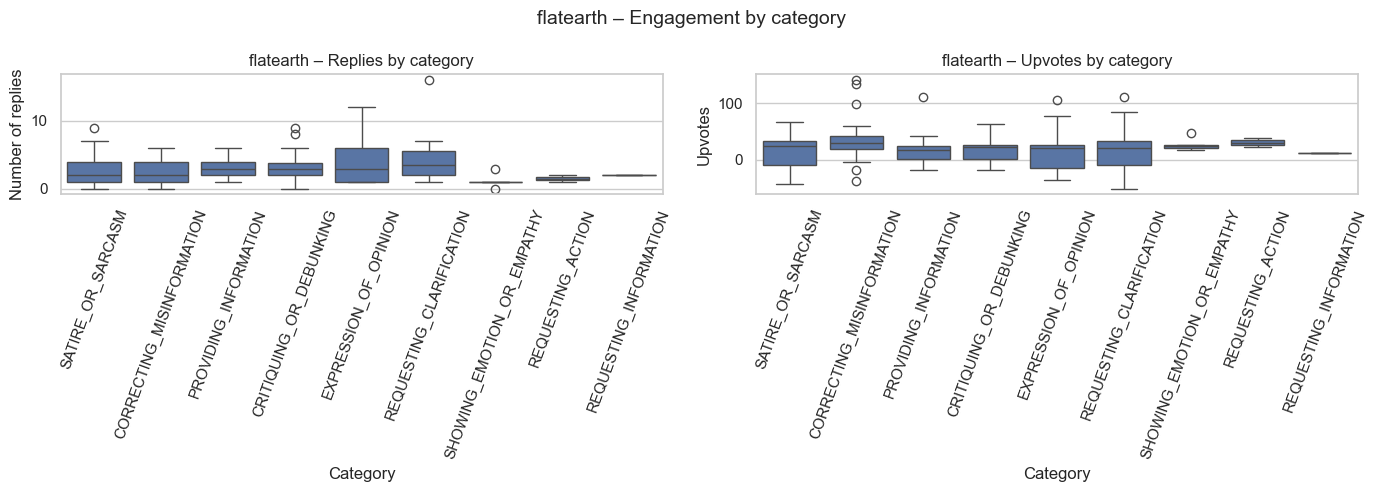

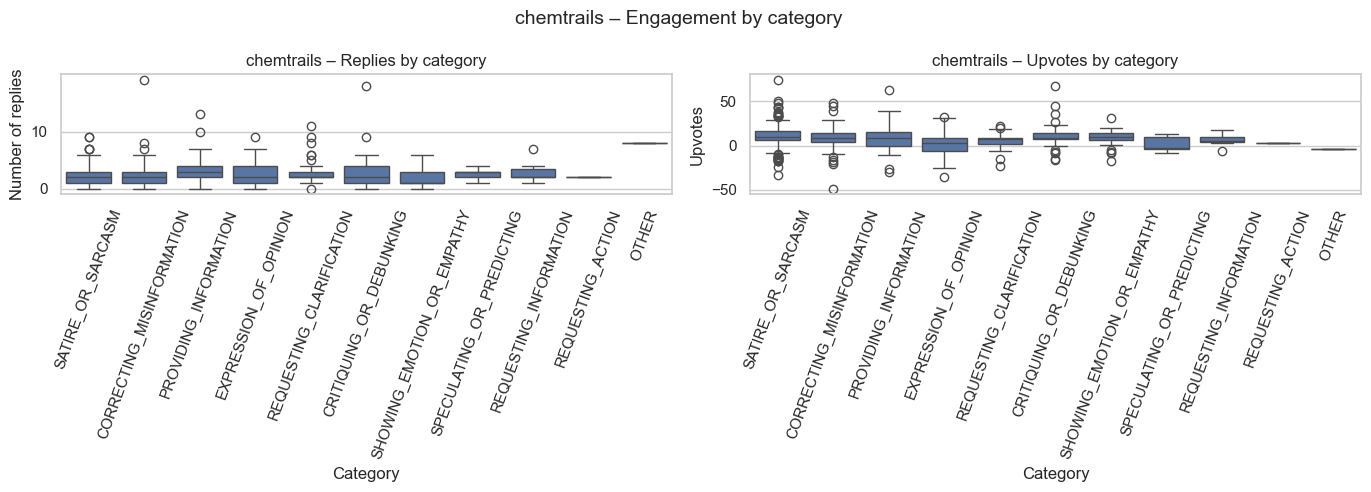

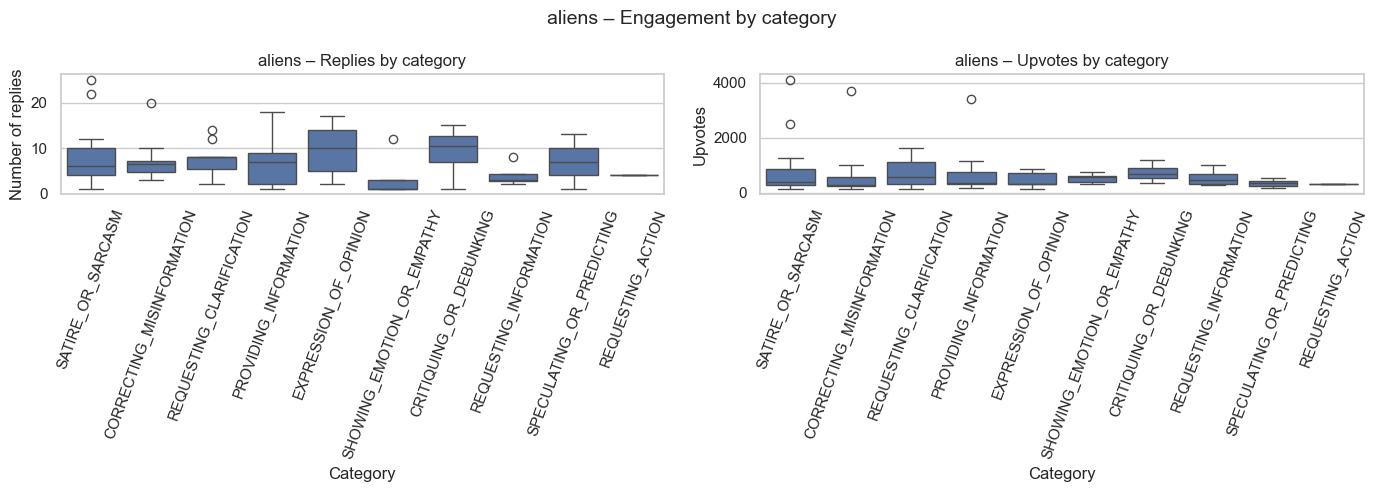

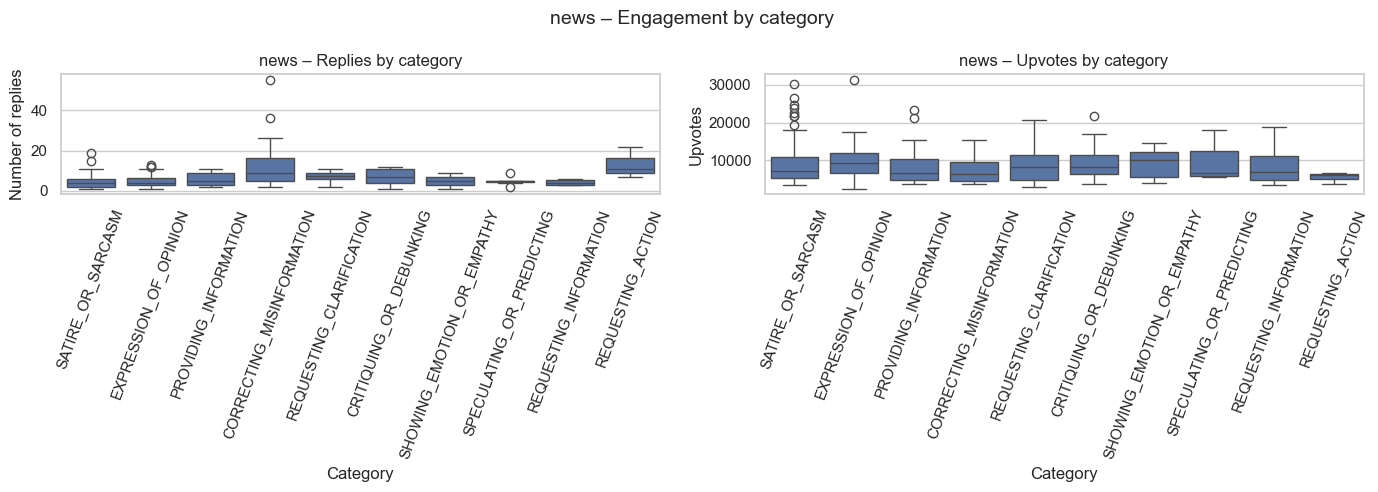

In [44]:
sns.set(style="whitegrid")

for name, df in df_dict.items():

    df_plot = df.dropna(subset=["category"])

    category_order = (
        df_plot["category"]
        .value_counts()
        .index
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

    sns.boxplot(
        data=df_plot,
        x="category",
        y="num_replies",
        order=category_order,
        ax=axes[0]
    )
    axes[0].set_title(f"{name} – Replies by category")
    axes[0].set_xlabel("Category")
    axes[0].set_ylabel("Number of replies")
    axes[0].tick_params(axis="x", rotation=70)

    sns.boxplot(
        data=df_plot,
        x="category",
        y="upvotes",
        order=category_order,
        ax=axes[1]
    )
    axes[1].set_title(f"{name} – Upvotes by category")
    axes[1].set_xlabel("Category")
    axes[1].set_ylabel("Upvotes")
    axes[1].tick_params(axis="x", rotation=70)

    fig.suptitle(f"{name} – Engagement by category", fontsize=14)
    plt.tight_layout()
    plt.show()